<a href="https://colab.research.google.com/github/Rebidex/IRA2_proiect_cercetare/blob/main/Proiect_IRA2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

cale_fisier = 'fisier primit din partea facultatii'

try:
    print("Se incarca fisierul.:P")

    df = pd.read_excel(cale_fisier)

    df.columns = df.columns.str.strip()
    df.rename(columns={df.columns[0]: 'Date'}, inplace=True)

    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df = df.dropna(subset=['Date'])
    df.set_index('Date', inplace=True)

    contoare_generale = ['ID_11', 'ID_21', 'ID_31', 'ID_41']
    df_generale = df[contoare_generale]

    print("\nTest de incarcare fisier. Cateva date: ")
    print(df_generale.head())

except Exception as e:
    print(f"A aparut o eroare: {e}")

Curățarea prin Thresholding a fost aplicată!


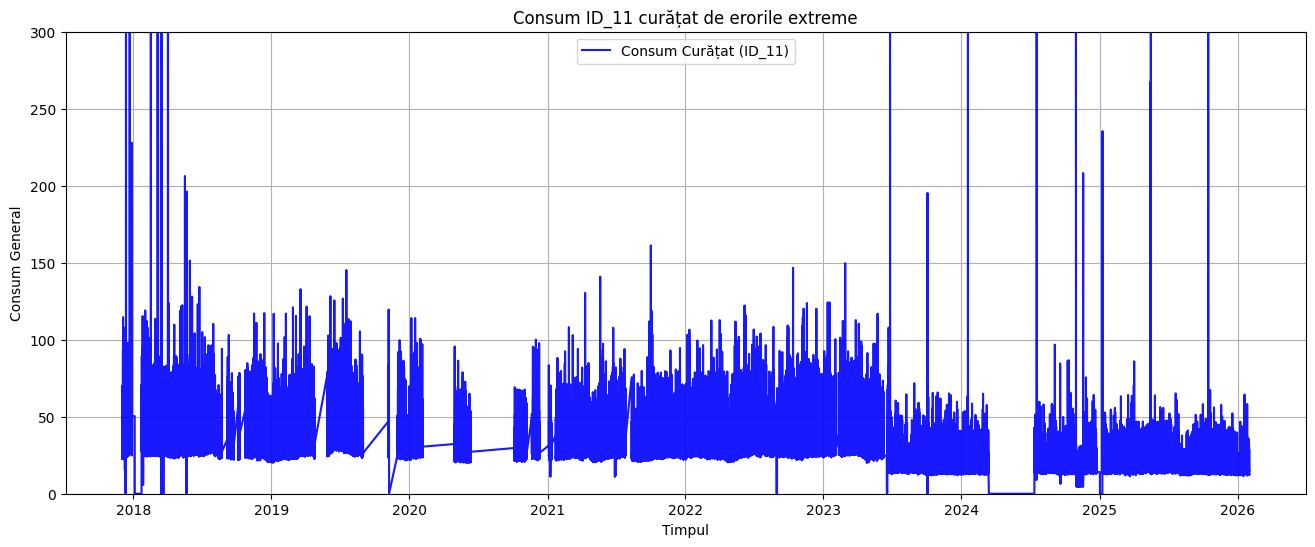

In [16]:
import numpy as np
import matplotlib.pyplot as plt

df_clean = df_generale.copy()
contoare_generale = ['ID_11', 'ID_21', 'ID_31', 'ID_41']

# thresholding
limita_maxima_rezonabila = 2000  # >2000 => eroare de senzor
limita_minima = 0                # consumul e imposibil sa fie negativ

for contor in contoare_generale:
    # NaN
    df_clean.loc[(df_clean[contor] > limita_maxima_rezonabila) | (df_clean[contor] < limita_minima), contor] = np.nan

    # interpolare
    df_clean[contor] = df_clean[contor].interpolate(method='time')
    df_clean[contor] = df_clean[contor].bfill().ffill()

print("Curatarea folosind thresholding este gata :D!")

plt.figure(figsize=(16, 6))

# date curate
plt.plot(df_clean.index, df_clean['ID_11'], label='Consum Curățat (ID_11)', color='blue', alpha=0.9)

plt.title('Consum ID_11 curățat de erorile extreme')
plt.xlabel('Timpul')
plt.ylabel('Consum General')

plt.ylim(0, 300)

plt.legend()
plt.grid(True)
plt.show()